In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import scanpy as sc
import anndata as ad
import scipy

from benchmark.BenchmarkUtils import loadSCData, tpSplitInd, tunedOurPars, splitBySpec
from plotting.__init__ import *
from plotting.visualization import plotPredAllTime, plotPredTestTime, computeDrift, plotStream, plotStreamByCellType
from plotting.PlottingUtils import umapWithPCA, computeLatentEmbedding
from optim.running import constructscNODEModel, scNODETrainWithPreTrain, scNODEPredict
from optim.evaluation import globalEvaluation
from umap import UMAP
from sklearn.decomposition import PCA
import geomloss

In [5]:
#adata = sc.read('/mnt/c/users/yannm/ubuntu_conda/data/schiebinger/schiebinger_100k_100g.h5ad')
#adata.X = adata.X.todense()
#adata = sc.read('/mnt/c/users/yannm/ubuntu_conda/data/cardasc_output/schiebinger_10k_DE_time.h5ad')
#adata.X = adata.X.todense()
#adata = sc.read("/mnt/c/users/yannm/ubuntu_conda/benchmark/data/data_1.h5ad")
adata = sc.read('/mnt/c/users/yannm/ubuntu_conda/git/Mechanistic_Trajectory_Models_Benchmark_private/benchmark/data/data_1.h5ad')
#sc.pp.normalize_total(adata)
#sc.pp.log1p(adata)

In [3]:
t_key = 't'

In [6]:
cell_tps = adata.obs[t_key] + 1
n_tps = len(np.unique(adata.obs[t_key]))
n_genes = adata.shape[1]
cell_types = None

In [7]:
np.unique(cell_tps)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [ ]:
train_tps = np.linspace(0, 9, 10, dtype='int')
test_tps = np.linspace(10, 14, 5, dtype='int')

In [7]:
if scipy.sparse.issparse(adata.X):
    adata.X = adata.X.toarray()
data = adata.X

In [8]:
data.shape

(10000, 119)

In [9]:
# Convert to torch project
traj_data = [torch.FloatTensor(data[np.where(cell_tps == t)[0]]) for t in np.unique(cell_tps)]
if cell_types is not None:
    traj_cell_types = [cell_types[np.where(cell_tps == t)[0]] for t in range(1, n_tps + 1)]

In [10]:
all_tps = list(np.unique(adata.obs[t_key]))
train_data = [traj_data[np.where(np.unique(adata.obs['t'])==t)[0][0]] for t in train_tps]
test_data = [traj_data[np.where(np.unique(adata.obs['t'])==t)[0][0]] for t in test_tps]
tps = torch.FloatTensor(all_tps)
train_tps = torch.FloatTensor(train_tps)
test_tps = torch.FloatTensor(test_tps)
n_cells = [each.shape[0] for each in traj_data]
print("# tps={}, # genes={}".format(n_tps, n_genes))
print("# cells={}".format(n_cells))
print("Train tps={}".format(train_tps))
print("Test tps={}".format(test_tps))

# tps=37, # genes=119
# cells=[181, 138, 151, 78, 406, 304, 285, 369, 363, 303, 366, 283, 374, 155, 271, 224, 165, 308, 239, 184, 194, 152, 155, 136, 170, 162, 157, 205, 337, 314, 383, 538, 421, 499, 368, 343, 319]
Train tps=tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
        28., 29.])
Test tps=tensor([30., 31., 32., 33., 34., 35., 36.])


In [11]:
# ======================================================
# Model training
pretrain_iters = 200
pretrain_lr = 1e-3
latent_coeff = 1 # regularization coefficient: beta
epochs = 2
iters = 100
batch_size = 100
lr = 5e-3
act_name = "relu"
n_sim_cells = 200
latent_dim = 10
drift_latent_size = [50, 50]
enc_latent_list = None
dec_latent_list = None

In [12]:
latent_ode_model = constructscNODEModel(
    n_genes, latent_dim=latent_dim,
    enc_latent_list=enc_latent_list, dec_latent_list=dec_latent_list, drift_latent_size=drift_latent_size,
    latent_enc_act="none", latent_dec_act=act_name, drift_act=act_name,
    ode_method="euler"
)
latent_ode_model, loss_list, recon_obs, first_latent_dist, latent_seq = scNODETrainWithPreTrain(
    train_data, train_tps, latent_ode_model, latent_coeff=latent_coeff, epochs=epochs, iters=iters,
    batch_size=batch_size, lr=lr, pretrain_iters=pretrain_iters, pretrain_lr=pretrain_lr
)

[ Epoch 2 ]: 100%|██████████| 100/100 [01:08<00:00,  1.45it/s, Loss=89481.797 | OT=80717.578, Dynamic_Reg=8764.216] 


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: CMU Serif


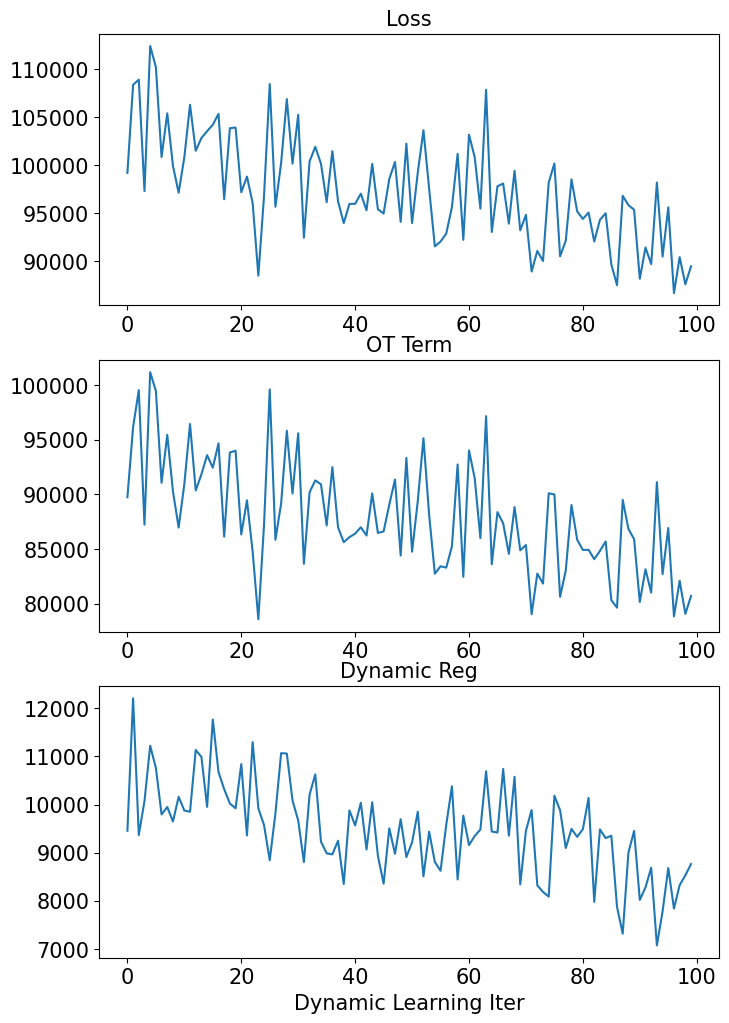

In [13]:
# ======================================================
# Visualization - loss curve
plt.figure(figsize=(8, 12))
plt.subplot(3, 1, 1)
plt.title("Loss")
plt.plot([each[0] for each in loss_list[100:]])
plt.subplot(3, 1, 2)
plt.title("OT Term")
plt.plot([each[1] for each in loss_list[100:]])
plt.subplot(3, 1, 3)
plt.title("Dynamic Reg")
plt.plot([each[2] for each in loss_list[100:]])
plt.xlabel("Dynamic Learning Iter")
plt.show()

In [14]:
def Wasserstein(true_data, pred_data):
    '''Evaluate the Wasserstein distance between true and reconstructed data at a single time point.'''
    assert true_data.shape[1] == pred_data.shape[1]
    ot_solver = geomloss.SamplesLoss("sinkhorn", p=2, blur=0.05, scaling=0.5, debias=True, backend="tensorized")
    # ot_solver = SamplesLoss("sinkhorn", p=2, blur=0.05, scaling=1.0, debias=True, backend="tensorized")
    if isinstance(true_data, np.ndarray):
        true_data = torch.DoubleTensor(true_data)
    if isinstance(true_data, torch.FloatTensor):
        true_data = torch.DoubleTensor(true_data.detach().numpy())
    if isinstance(pred_data, np.ndarray):
        pred_data = torch.DoubleTensor(pred_data)
    if isinstance(pred_data, torch.FloatTensor):
        pred_data = torch.DoubleTensor(pred_data.detach().numpy())
    ot_loss = ot_solver(true_data, pred_data).item()
    return ot_loss

# Full Pred from t=0 

In [17]:
test_times = test_tps.detach().numpy()
test_times = [int(i) for i in test_times]
train_times = train_tps.detach().numpy()
train_times = [int(i) for i in train_times]

In [18]:
all_recon_obs = scNODEPredict(latent_ode_model, traj_data[0], tps, n_cells=n_sim_cells)

In [19]:
list_times_pred = []
for i in tps.cpu().numpy():
    list_times_pred+= [i] * n_sim_cells
pred_adata = ad.AnnData(np.reshape(all_recon_obs,newshape=(n_sim_cells*len(tps),n_genes)))
pred_adata.obs['t'] = list_times_pred

In [22]:
#truth = traj_data[t].detach().numpy()
#pred = all_recon_obs[:, t, :]

In [17]:
tps_list = [int(t) for t in tps]
dist_list = []
for t in tps_list:    
    pred_global_metric = globalEvaluation(traj_data[t].detach().numpy(), all_recon_obs[:, t, :])
    dist_list.append([t , pred_global_metric['ot']])
list_wasserstein = [dist_list[i][1] for i in range(len(dist_list))]

# Extrapol from end of training timepoints

In [15]:
test_times = test_tps.detach().numpy()
test_times = [int(i) for i in test_times]
train_times = train_tps.detach().numpy()
train_times = [int(i) for i in train_times]

In [18]:
all_recon_obs = scNODEPredict(latent_ode_model, traj_data[len(train_times)-1], test_tps, n_cells=n_sim_cells)

In [19]:
list_times_pred = []
for i in test_tps.cpu().numpy():
    list_times_pred+= [i] * n_sim_cells
pred_adata = ad.AnnData(np.reshape(all_recon_obs,newshape=(n_sim_cells*len(test_tps),n_genes)))
pred_adata.obs['t'] = list_times_pred

In [36]:
reducer = UMAP(random_state=42, min_dist=.7, n_neighbors = 30)
X_input = pred_adata.X
proj = reducer.fit(X_input)
pred_adata.obsm["X_umap"] = proj.transform(X_input)

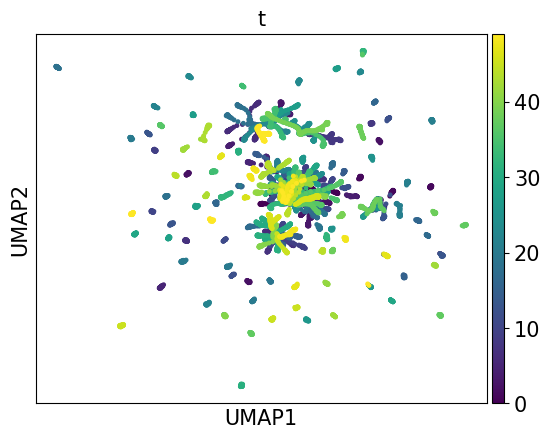

In [37]:
sc.pl.umap(pred_adata, color = 't', size = 50)

In [84]:
dist_list = []
for t in test_times:    
    pred_global_metric = globalEvaluation(traj_data[np.where(np.unique(adata.obs['t'])==t)[0][0]].detach().numpy(), 
                                          all_recon_obs[:, np.where(np.array(test_times)==t)[0][0], :])
    dist_list.append([t , pred_global_metric['ot']])
list_wasserstein = [dist_list[i][1] for i in range(len(dist_list))]

In [20]:
from umap import UMAP

In [21]:
reducer = UMAP(random_state=42, min_dist=.7, n_neighbors = 30)
X_input = adata.X
proj = reducer.fit(X_input)
adata.obsm["X_umap"] = proj.transform(X_input)
pred_adata.obsm["X_umap"] = proj.transform(pred_adata.X)

/home/yannm/anaconda3/envs/sc_dynamic/lib/python3.7/site-packages/scipy/sparse/_index.py:125: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


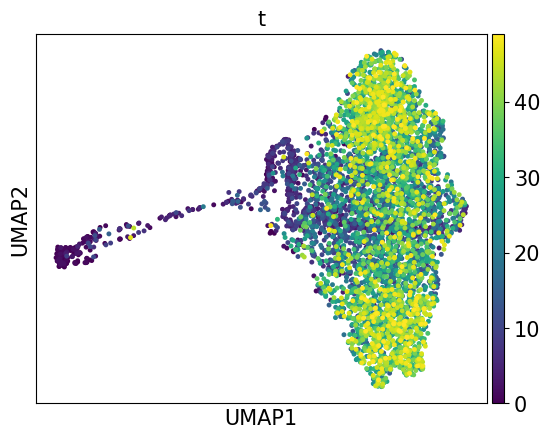

In [22]:
sc.pl.umap(adata, color = 't', size = 50)

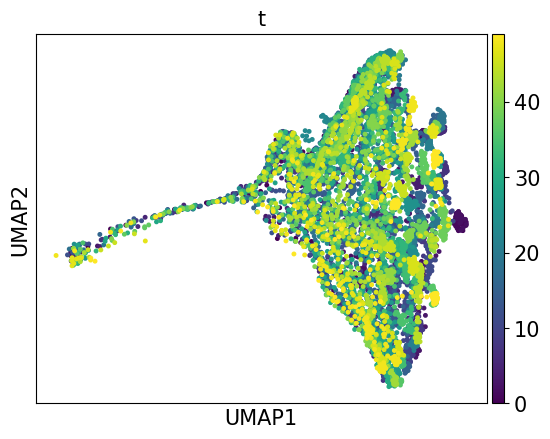

In [23]:
sc.pl.umap(pred_adata, color = 't', size = 50)

In [85]:
list_wasserstein

[2.1879398592525297, 2.3986533697034167]

In [45]:
np.save('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/scnode_extrapol_20_10k_t', list_wasserstein)

In [42]:
list_times_pred = []
for i in test_tps.cpu().numpy():
    list_times_pred+= [i] * n_sim_cells
pred_adata = ad.AnnData(np.reshape(all_recon_obs,newshape=(n_sim_cells*len(test_tps),n_genes)))
pred_adata.obs['t'] = list_times_pred
pred_adata.write_h5ad('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/scnode_extrapol_20_10k_t.h5ad')

# Interpolation from neighbor

In [15]:
test_tps_list = [int(t) for t in test_tps]
dist_list = []
for t in test_tps_list:
    interpol_obs = scNODEPredict(latent_ode_model, traj_data[t-1], torch.FloatTensor([t]), n_cells=n_sim_cells)
    pred_global_metric = globalEvaluation(traj_data[t].detach().numpy(), interpol_obs[:,0,:])
    dist_list.append([t , pred_global_metric['ot']])
list_wasserstein = [dist_list[i][1] for i in range(len(dist_list))]

In [20]:
list_wasserstein

[19.695963800145222,
 20.47759276076,
 26.244514436241857,
 26.020695125080966,
 14.542446241486267,
 16.635652296742634,
 17.156307401120767,
 16.87698980894289,
 18.421281704818373,
 23.756696373619597,
 27.18214053337076,
 26.03741956448335,
 27.529987316669043,
 44.15477383743465,
 24.911096509856964,
 24.376471000730554,
 26.91774461576741,
 23.443889878947036]

In [21]:
np.mean(list_wasserstein)

23.57675906701213

In [22]:
np.save('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/scnode_interpol_10k_t', list_wasserstein)

# Plot wasserstein-test timepoints

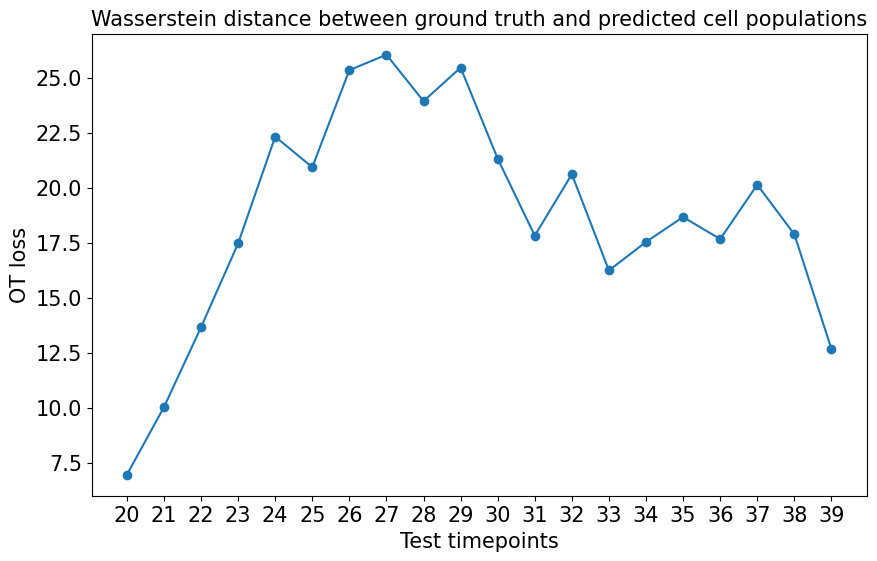

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(list_wasserstein, marker='o')
plt.xlabel('Test timepoints')
plt.ylabel('OT loss')
plt.title('Wasserstein distance between ground truth and predicted cell populations')
plt.xticks(range(len(list_wasserstein)), test_times) 
plt.grid(False)
plt.savefig("/mnt/c/users/yannm/documents/COMPO/project/sc_node/Wasserstein_prediction_extrapol_0-20")
#plt.show()

# Plot Heatmap train timepoints - test timepoints

In [33]:
#Ground truth array
true_heatmap_array = []
for i, test in enumerate(test_times):
    print(i)
    true_heatmap_array.append([])
    for train in train_times:
        true_heatmap_array[i].append(Wasserstein(adata[adata.obs['t']== train].X, adata[adata.obs['t'] == test].X))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [50]:
#Pred array
pred_heatmap_array = []
for i, test in enumerate(test_times):
    pred_data = scNODEPredict(latent_ode_model, traj_data[test-1], torch.FloatTensor([test]), n_cells=n_sim_cells)
    pred_heatmap_array.append([])
    for train in train_times:
        pred_heatmap_array[i].append(Wasserstein(adata[adata.obs['t']==train].X, pred_data[:,0,:]))

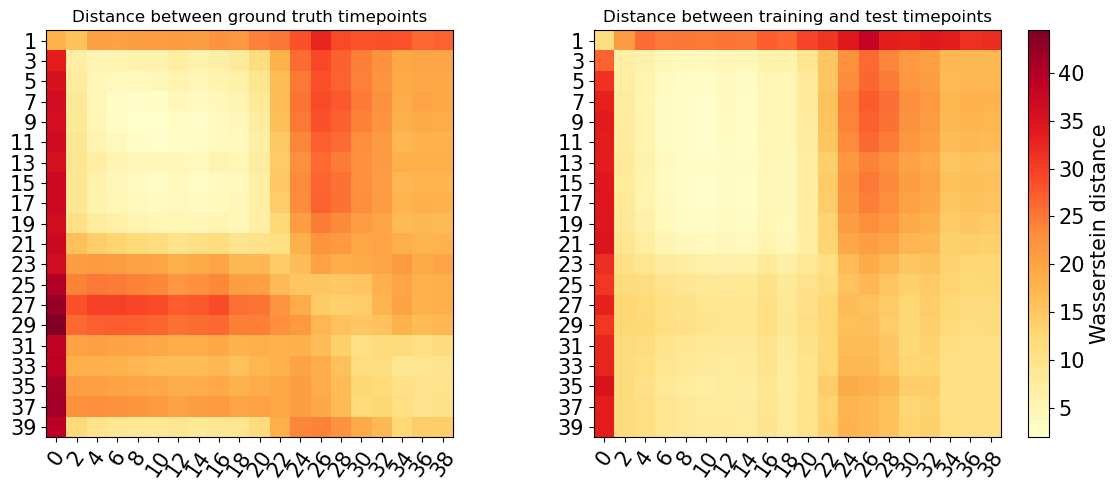

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

global_min = min(np.min(true_heatmap_array), np.min(pred_heatmap_array))
global_max = max(np.max(true_heatmap_array), np.max(pred_heatmap_array))

im1 = axes[0].imshow(true_heatmap_array, cmap = "YlOrRd", vmin=global_min, vmax=global_max)
axes[0].set_title("Distance between ground truth timepoints", fontsize=12)
axes[0].set_xticks(range(len(train_times)))
axes[0].set_xticklabels(labels=train_times, rotation=55)
axes[0].set_yticks(range(len(test_times)))
axes[0].set_yticklabels(labels=test_times)
im2 = axes[1].imshow(pred_heatmap_array, cmap = "YlOrRd", vmin=global_min, vmax=global_max)
axes[1].set_title("Distance between training and test timepoints", fontsize=12)
axes[1].set_xticks(range(len(train_times)))
axes[1].set_xticklabels(labels=train_times, rotation=55)
axes[1].set_yticks(range(len(test_times)))
axes[1].set_yticklabels(labels=test_times)
fig.colorbar(im2, ax=axes[1], label='Wasserstein distance')
axes[0].grid(False)
axes[1].grid(False)
plt.tight_layout()
plt.savefig("/mnt/c/users/yannm/documents/COMPO/project/sc_node/heatmaps_scnode")
#plt.show()

# Visualisation

In [14]:
true_data = [each.detach().numpy() for each in traj_data]
reorder_pred_data = [all_recon_obs[:, t, :] for t in range(all_recon_obs.shape[1])]

In [16]:
def plot_UMAP_pred_true(true_data, pred_data, start, end, compare, point_size):
    true_cell_tps = np.concatenate([np.repeat(t+start, each.shape[0]) for t, each in enumerate(true_data[slice(start, end+1)])])
    pred_cell_tps = np.concatenate([np.repeat(t+start, each.shape[0]) for t, each in enumerate(reorder_pred_data[slice(start, end+1)])])
    pca_model = PCA(n_components=50, svd_solver="arpack")
    umap_model = UMAP(n_components=2, n_neighbors=50)
    true_umap_traj = umap_model.fit_transform(pca_model.fit_transform(np.concatenate(true_data[slice(start, end+1)], axis=0)))
    pred_umap_traj = umap_model.transform(pca_model.transform(np.concatenate(pred_data[slice(start, end+1)], axis=0)))
    
    color_list = Vivid_10.mpl_colors
    #color_list = linearSegmentCMap(len(compare), "viridis")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.set_title("True Data", fontsize=15)
    ax2.set_title("Predictions", fontsize=15)
    ax1.scatter(true_umap_traj[:, 0], true_umap_traj[:, 1], label="other", c=np.array(gray_color).reshape(1,-1), s=point_size, alpha=0.5)
    ax2.scatter(true_umap_traj[:, 0], true_umap_traj[:, 1], label="other", c=np.array(gray_color).reshape(1,-1), s=point_size, alpha=0.5)
    for i, t in enumerate(compare):
        color = color_list[i]
        true_t_idx = np.where(true_cell_tps == t)[0]
        pred_t_idx = np.where(pred_cell_tps == t)[0]
        ax1.scatter(true_umap_traj[true_t_idx, 0], true_umap_traj[true_t_idx, 1], label=int(t), color=color, s=point_size, alpha=1.0)
        ax2.scatter(pred_umap_traj[pred_t_idx, 0], pred_umap_traj[pred_t_idx, 1], label=int(t), color=color, s=point_size, alpha=1.0)
    ax2.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    # plt.tight_layout()
    #plt.savefig()
    plt.show()

In [17]:
import warnings
warnings.filterwarnings("ignore")

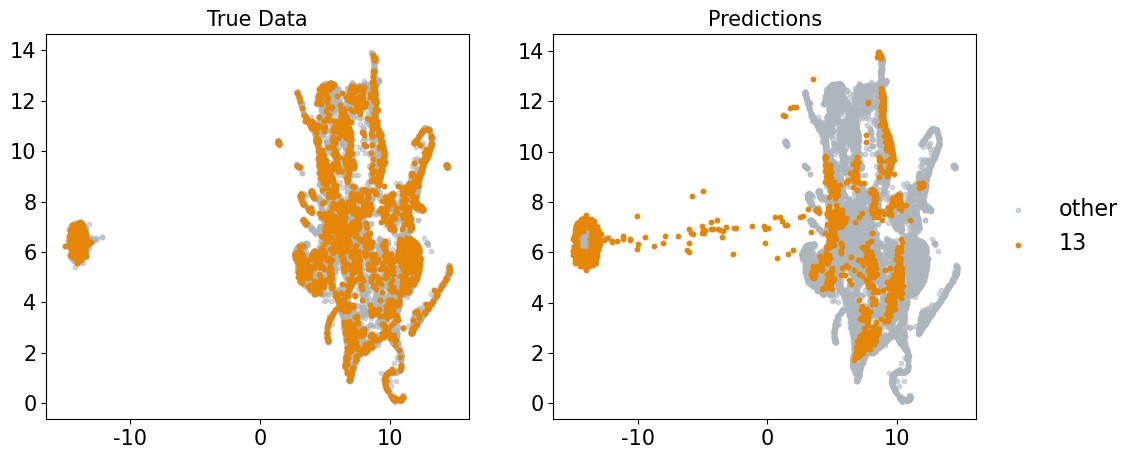

In [21]:
plot_UMAP_pred_true(true_data, reorder_pred_data, start=10, end=15, compare=[13], point_size=10)